In [ ]:

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [12]:
df = pd.read_csv("DATAELEMENTDESCRIPTION.csv")
df

,index,PAGE_NAME,COLUMN_NAME,DATA_TYPE,IS_PERCENT_DATA,DESCRIPTION,REFERENCE
0,0,Demographics,State_FIPS_Code,Text,N,"Two-digit state identifier, developed by the N...","Data Sources, Definitions, and Notes, Page 6"
1,1,Demographics,County_FIPS_Code,Text,N,"Three-digit county identifier, developed by th...","Data Sources, Definitions, and Notes, Page 6"
2,2,Demographics,CHSI_County_Name,Text,N,Name of county,NaN
3,3,Demographics,CHSI_State_Name,Text,N,Name of State or District of Columbia,NaN
4,4,Demographics,CHSI_State_Abbr,Text,N,Two-character postal abbreviation for state name,NaN
...,...,...,...,...,...,...,...
573,573,RiskFactorsAndAccessToCare,Disabled_Medicare,Integer,N,"County data, medicare beneficiaries, disabled","Data Sources, Definitions, and Notes, Page 29"
574,574,RiskFactorsAndAccessToCare,Prim_Care_Phys_Rate,Decimal,N,"County data, primary care physicians per 100,0...","Data Sources, Definitions, and Notes, Page 30"
575,575,RiskFactorsAndAccessToCare,Dentist_Rate,Decimal,N,"County data, dentists per 100,000 pop.","Data Sources, Definitions, and Notes, Page 30"
576,576,RiskFactorsAndAccessToCare,Community_Health_Center_Ind,Integer,N,Indicator for any Community/Migrant Health Cen...,"Data Sources, Definitions, and Notes, Page 30"


In [13]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 578 entries, 0 to 577
Data columns (total 7 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   index            578 non-null    int64 
 1   PAGE_NAME        578 non-null    object
 2   COLUMN_NAME      578 non-null    object
 3   DATA_TYPE        578 non-null    object
 4   IS_PERCENT_DATA  578 non-null    object
 5   DESCRIPTION      578 non-null    object
 6   REFERENCE        552 non-null    object
dtypes: int64(1), object(6)
memory usage: 31.7+ KB


In [14]:
df.describe()

,index
count,578.000000
mean,288.500000
std,166.998503
min,0.000000
25%,144.250000
50%,288.500000
75%,432.750000
max,577.000000


In [15]:
df.isnull().sum()

index               0
PAGE_NAME           0
COLUMN_NAME         0
DATA_TYPE           0
IS_PERCENT_DATA     0
DESCRIPTION         0
REFERENCE          26
dtype: int64

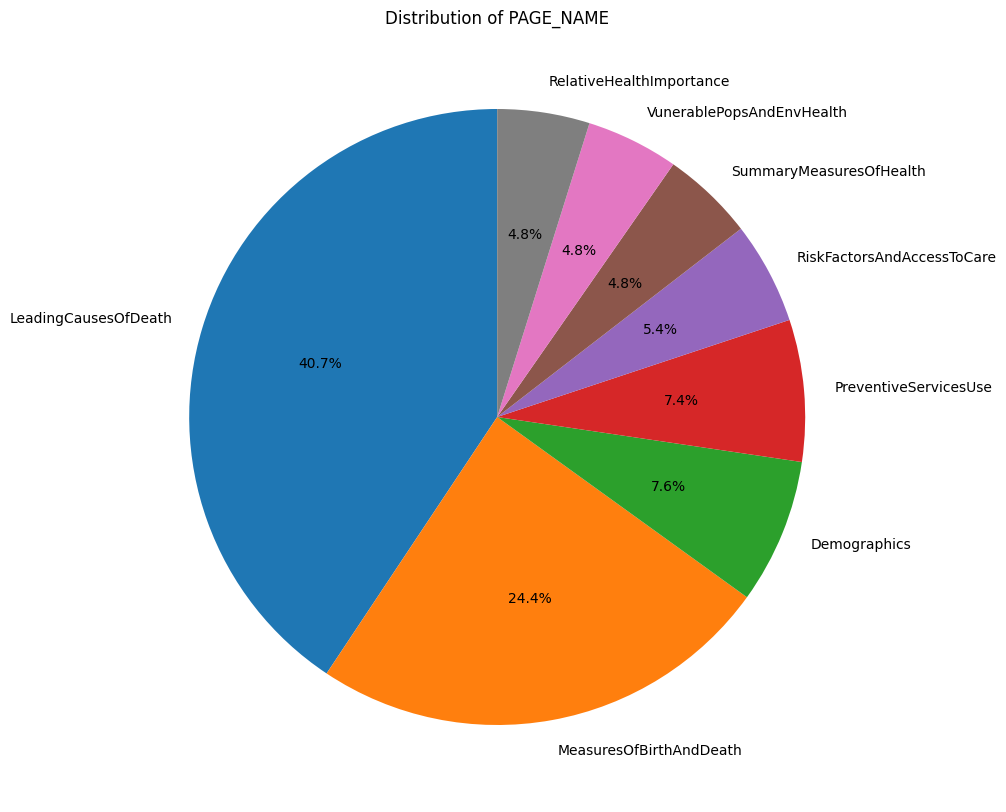

In [16]:
page_count = df['PAGE_NAME'].value_counts()

plt.figure(figsize=(10,10))
plt.pie(page_count,
        labels=page_count.index,
        autopct='%1.1f%%',
        startangle=90)

plt.title('Distribution of PAGE_NAME')
plt.show()

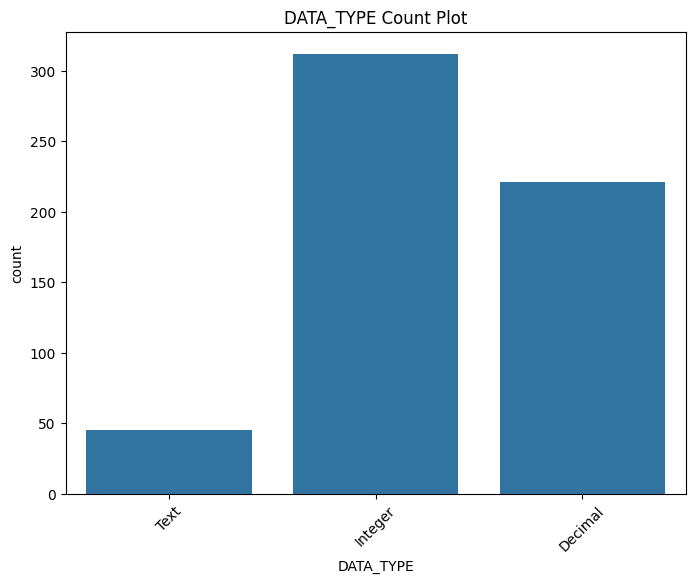

In [18]:
#Countplot
plt.figure(figsize=(8,6))
sns.countplot(
    x='DATA_TYPE',
    data=df
)
plt.title("DATA_TYPE Count Plot")
plt.xticks(rotation=45)
plt.show()

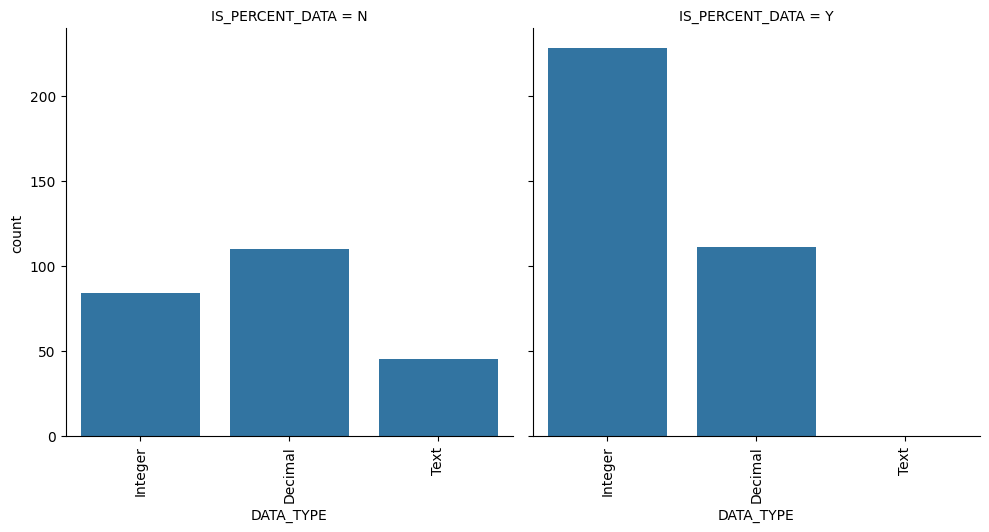

In [19]:
#FacetGrid
g = sns.FacetGrid(
    df,
    col="IS_PERCENT_DATA",
    height=5
)

g.map_dataframe(
    sns.countplot,
    x="DATA_TYPE",
    order=df["DATA_TYPE"].value_counts().index
)

g.set_xticklabels(rotation=90)
plt.show()

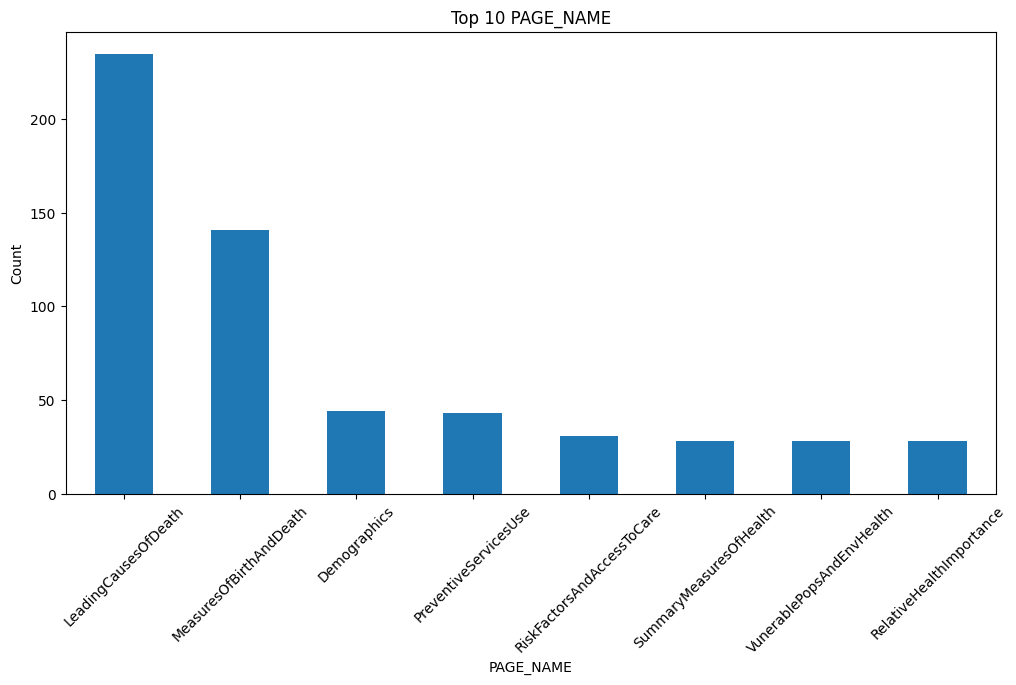

In [20]:
plt.figure(figsize=(12,6))

df['PAGE_NAME'].value_counts().head(10).plot(
    kind='bar'
)

plt.title('Top 10 PAGE_NAME')
plt.xlabel('PAGE_NAME')
plt.ylabel('Count')
plt.xticks(rotation=45)
plt.show()

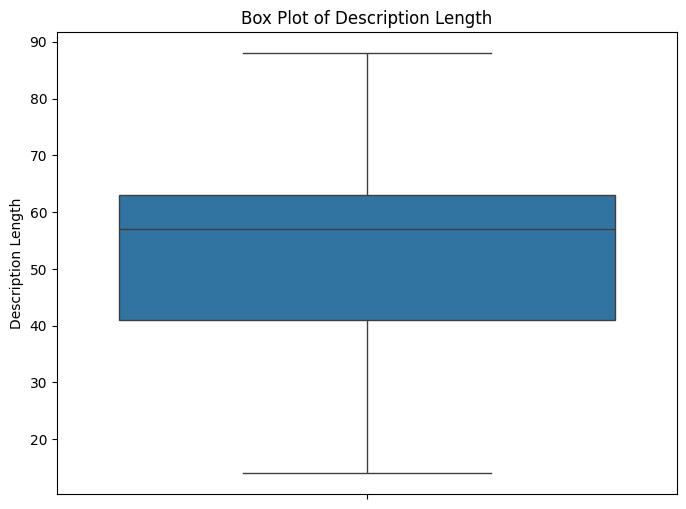

In [21]:
df['description_length'] = df['DESCRIPTION'].fillna('').apply(len)

plt.figure(figsize=(8,6))
sns.boxplot(
    y='description_length',
    data=df
)

plt.title('Box Plot of Description Length')
plt.ylabel('Description Length')
plt.show()

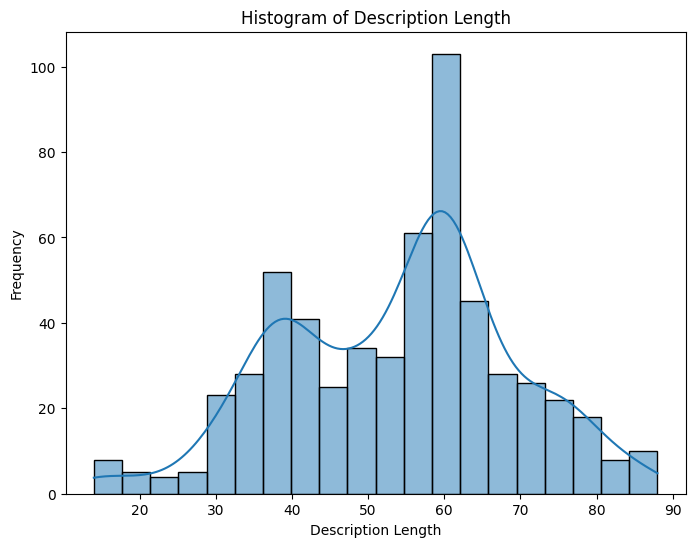

In [22]:

# Histplot
plt.figure(figsize=(8,6))
sns.histplot(
    x='description_length',
    data=df,
    bins=20,
    kde=True
)

plt.title('Histogram of Description Length')
plt.xlabel('Description Length')
plt.ylabel('Frequency')
plt.show()